In [1]:
!pip install numpy pandas matplotlib scikit-learn tensorflow opencv-python

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
np.random.seed(42)

size = 300
living_area = np.random.randint(500, 4000, size)
price = living_area * 120 + np.random.randint(-50000, 50000, size)
expensive = (price > 250000).astype(int)

housing_df = pd.DataFrame({
    "LivingArea": living_area,
    "Price": price,
    "Expensive": expensive
})

housing_df.head()

,LivingArea,Price,Expensive
0,3674,474643,1
1,1360,121880,0
2,1794,250176,1
3,1630,229479,0
4,1595,212695,0


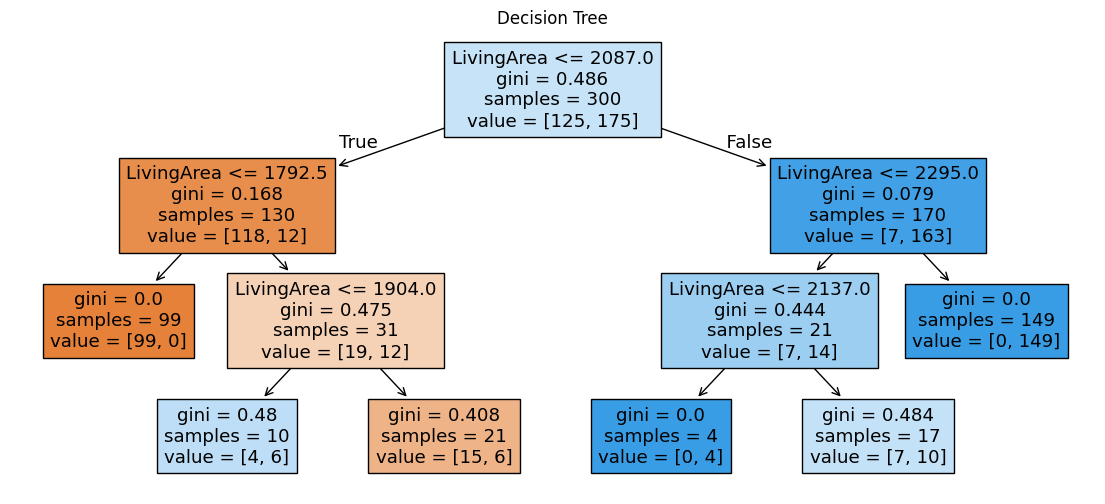

In [7]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

dt = DecisionTreeClassifier(max_depth=3)
dt.fit(X, y)

plt.figure(figsize=(14,6))
plot_tree(dt, feature_names=["LivingArea"], filled=True)
plt.title("Decision Tree")
plt.show()

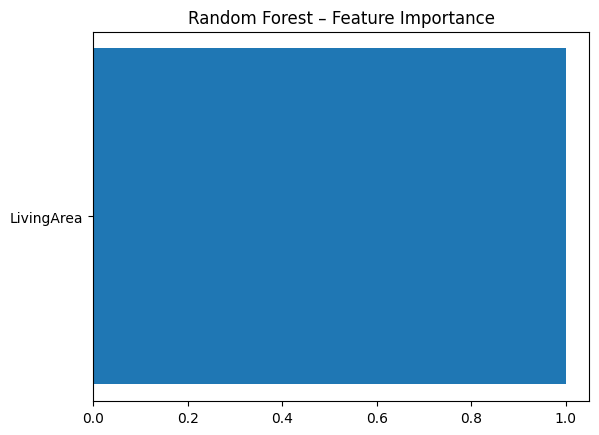

In [8]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100)
rf.fit(X, y)

plt.barh(["LivingArea"], rf.feature_importances_)
plt.title("Random Forest – Feature Importance")
plt.show()

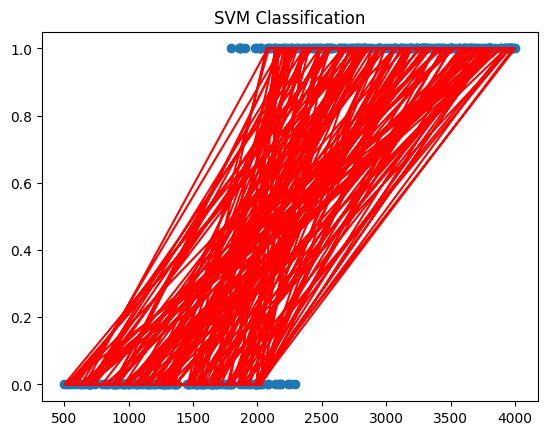

In [9]:
from sklearn.svm import SVC

svm = SVC(kernel="linear")
svm.fit(X, y)

plt.scatter(X, y)
plt.plot(X, svm.predict(X), color="red")
plt.title("SVM Classification")
plt.show()

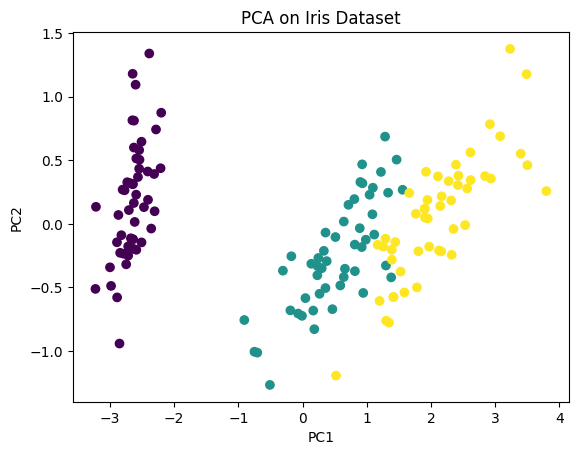

In [10]:
from sklearn.datasets import load_iris
from sklearn.decomposition import PCA

iris = load_iris()
X_iris = iris.data
y_iris = iris.target

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_iris)

plt.scatter(X_pca[:,0], X_pca[:,1], c=y_iris)
plt.title("PCA on Iris Dataset")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

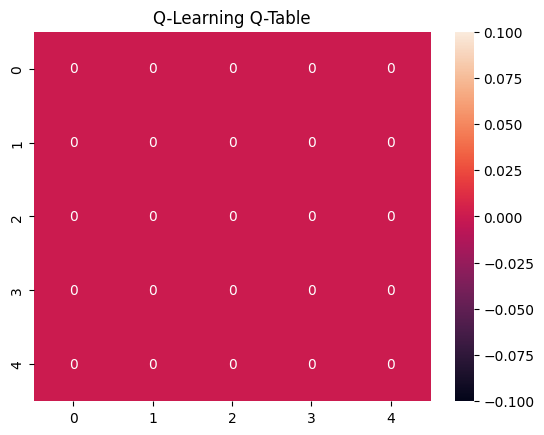

In [11]:
Q = np.zeros((5,5))

sns.heatmap(Q, annot=True)
plt.title("Q-Learning Q-Table")
plt.show()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


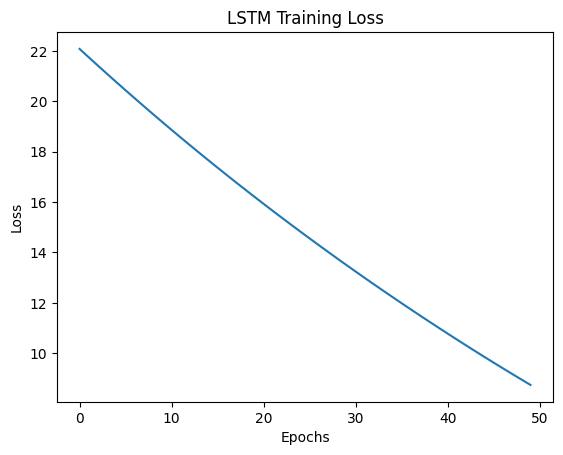

In [12]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

X_seq = np.array([
    [[1],[2],[3]],
    [[2],[3],[4]],
    [[3],[4],[5]]
])

y_seq = np.array([[4],[5],[6]])

lstm = Sequential([
    LSTM(20, input_shape=(3,1)),
    Dense(1)
])

lstm.compile(optimizer="adam", loss="mse")
history = lstm.fit(X_seq, y_seq, epochs=50, verbose=0)

plt.plot(history.history["loss"])
plt.title("LSTM Training Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.show()

In [13]:
from tensorflow.keras.layers import Dense

qnet = Sequential([
    Dense(24, activation="relu", input_dim=4),
    Dense(24, activation="relu"),
    Dense(2)
])

qnet.compile(optimizer="adam", loss="mse")
qnet.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_1 (Dense)                 │ (None, 24)             │           120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 24)             │           600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 2)              │            50 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 770 (3.01 KB)

 Trainable params: 770 (3.01 KB)

 Non-trainable params: 0 (0.00 B)